In [65]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


# 1. Import

In [66]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler          
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, cross_val_score   
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score   
)
from xgboost import XGBClassifier

# 2. Load Dataset

In [67]:
df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")

print("Shape:", df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [69]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [70]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


# 3. EDA

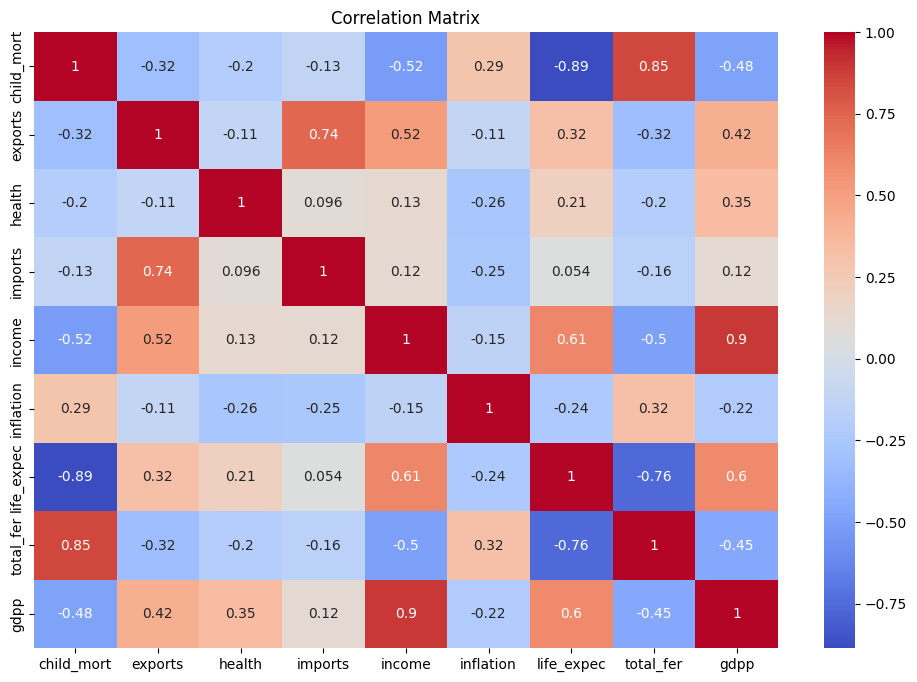

In [71]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop("country", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

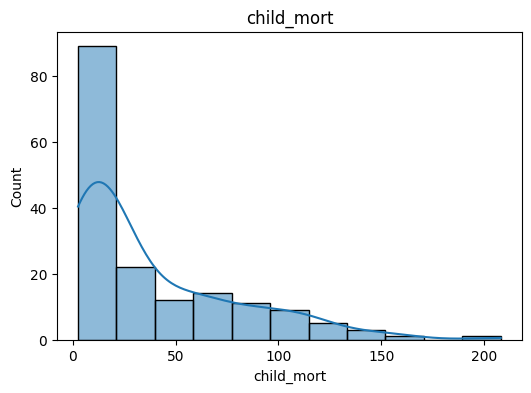

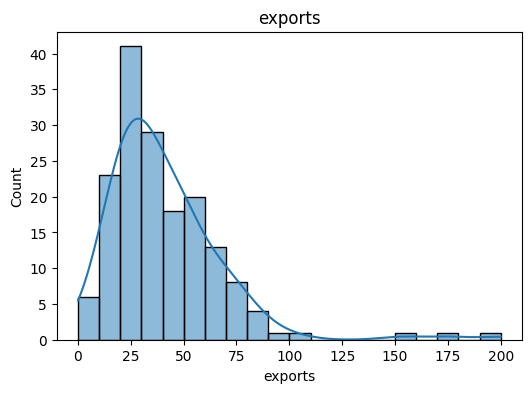

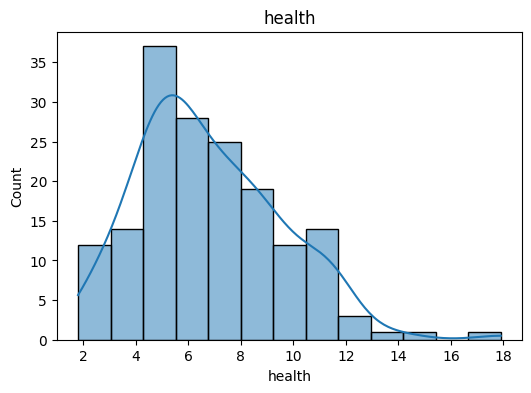

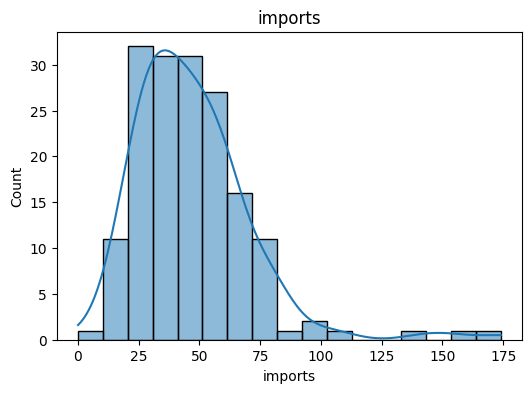

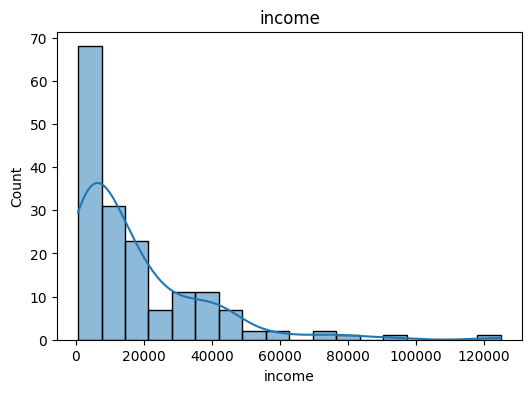

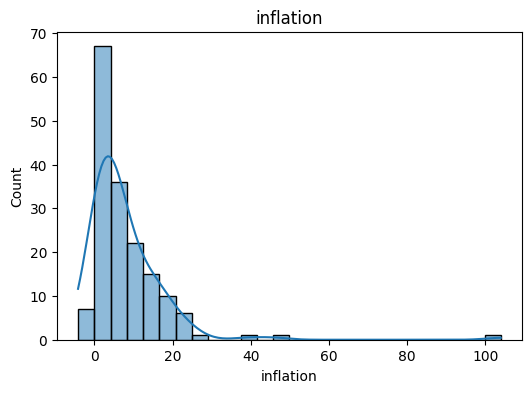

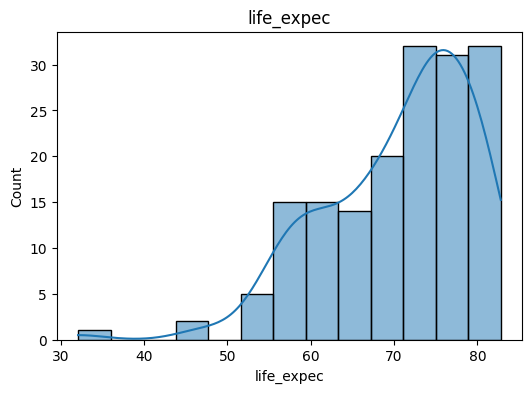

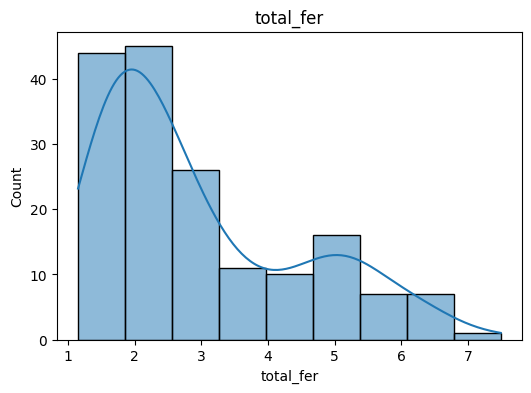

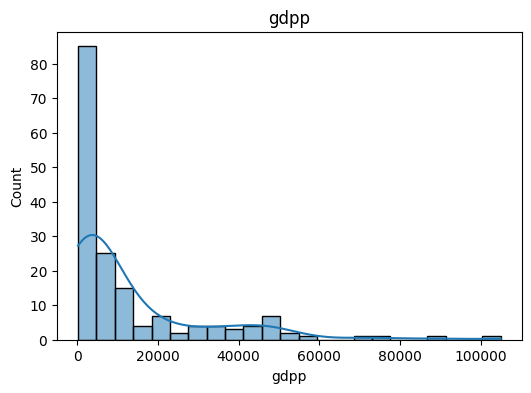

In [72]:
num_cols = df.columns[1:]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

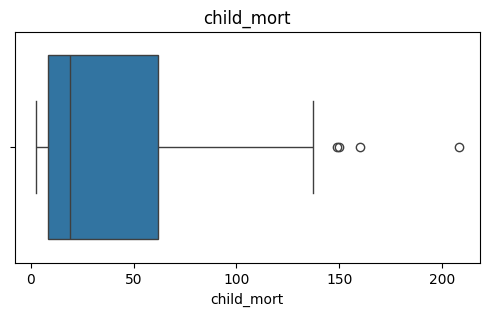

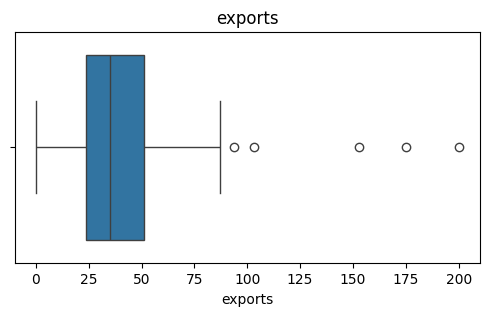

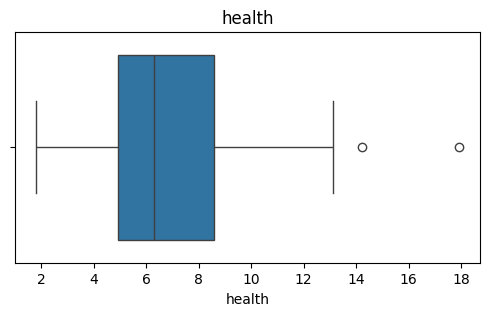

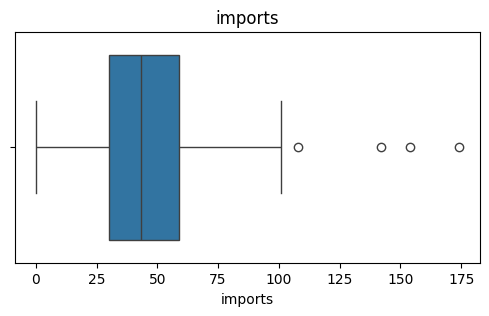

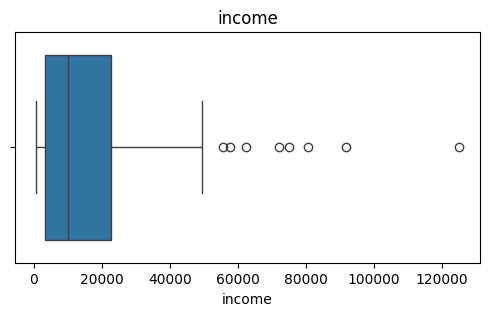

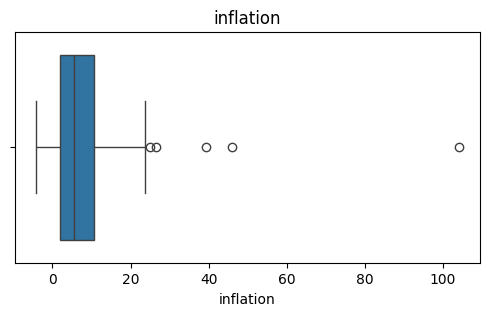

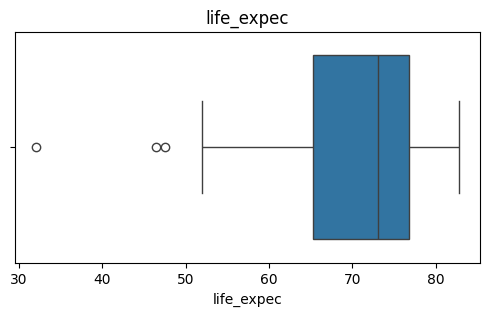

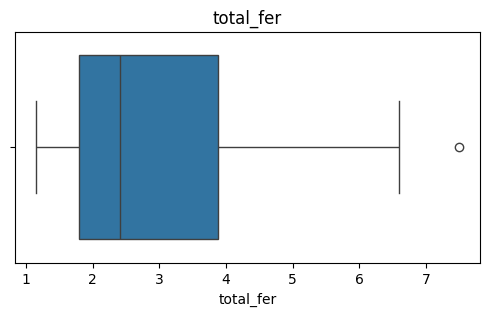

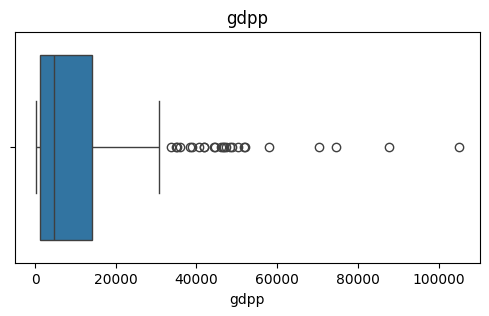

In [73]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# 4. Feature Engineering

In [74]:
X = df.drop("country", axis=1)

scaler = MinMaxScaler()                   
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242


# 5. Unsupervised Learning

## 5.1 Find Optimal Clusters

In [75]:
wcss = []
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    wcss.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

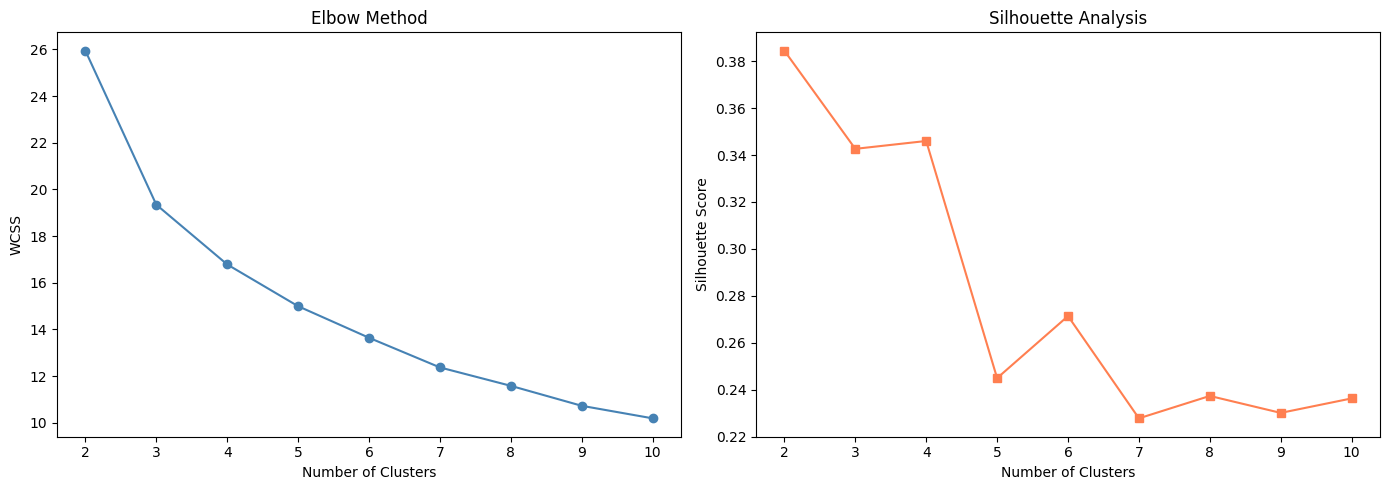

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(2, 11), wcss, marker='o', color='steelblue')
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("WCSS")
axes[0].set_title("Elbow Method")

axes[1].plot(range(2, 11), silhouette_scores, marker='s', color='coral')
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.show()

## 5.2 K-Means Clustering (k=3)

In [77]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

print("Silhouette Score (k=3):", round(silhouette_score(X_scaled, clusters), 4))
df["Cluster"].value_counts()

Silhouette Score (k=3): 0.3427


Cluster
2    87
1    46
0    34
Name: count, dtype: int64

## 5.3 Cluster Summary & Interpretation

In [78]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,4.835294,57.905882,8.921176,50.735294,46408.823529,2.595294,80.385294,1.750294,43897.058824
1,93.284783,29.287174,6.338478,43.297826,3516.804348,12.097065,59.393478,5.090217,1695.913043
2,22.248276,40.795276,6.245172,47.286964,12913.678161,7.527138,72.616092,2.283333,6833.356322


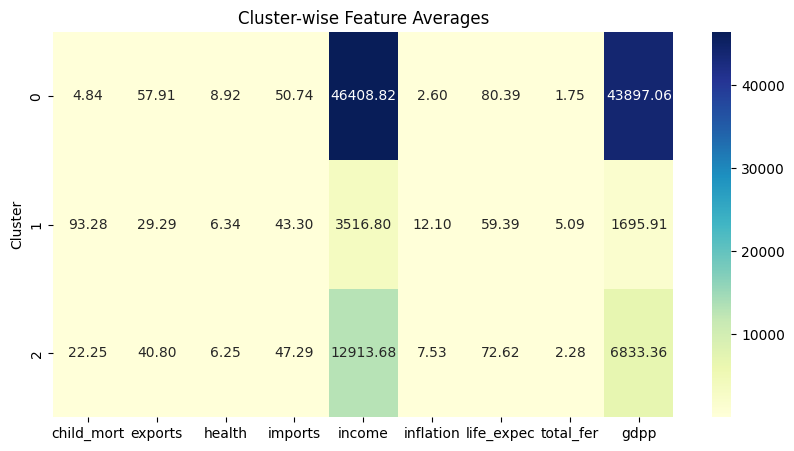

In [79]:
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_summary, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Cluster-wise Feature Averages")
plt.show()

## 5.4 Dimensionality Reduction using PCA

In [80]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained Variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

Explained Variance: PC1=55.00%, PC2=13.38%


In [81]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters

## 5.5 PCA Cluster Visualization

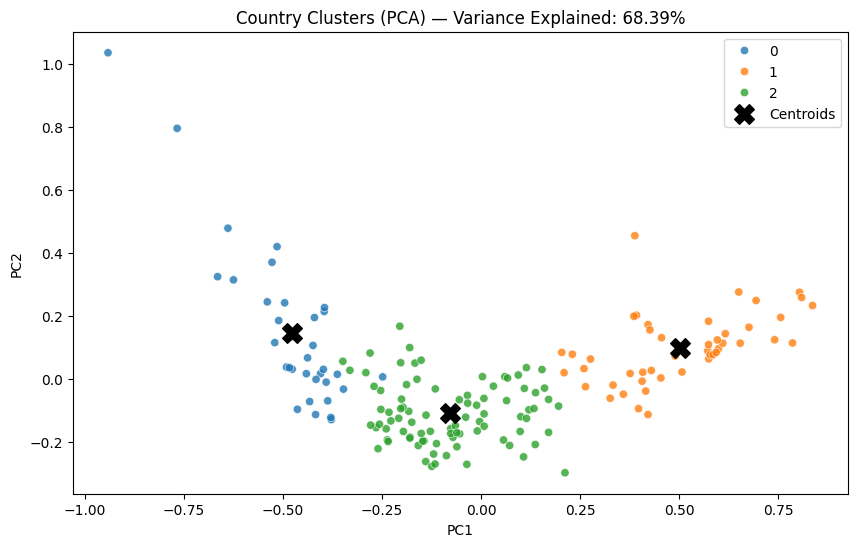

In [82]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=pca_df, palette="tab10", alpha=0.8)
centroids = pca_df.groupby("Cluster")[["PC1", "PC2"]].mean()
plt.scatter(centroids["PC1"], centroids["PC2"], s=200, marker="X", c="black", label="Centroids", zorder=5)

plt.title(f"Country Clusters (PCA) — Variance Explained: {sum(pca.explained_variance_ratio_):.2%}")
plt.legend()
plt.show()

## 5.6 DBSCAN — Parameter Selection via K-Distance Plot

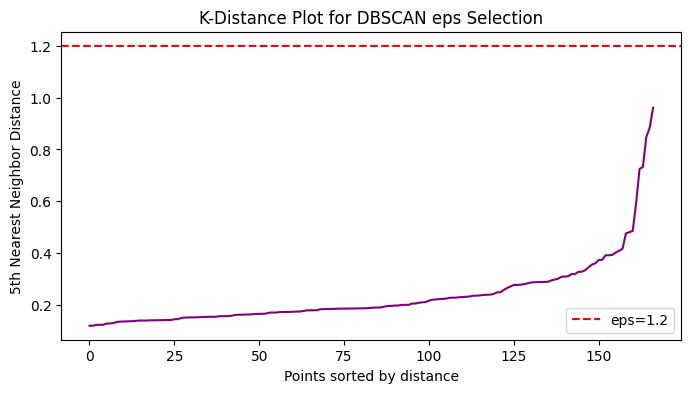

In [83]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 4))
plt.plot(distances, color='purple')
plt.axhline(y=1.2, color='red', linestyle='--', label='eps=1.2')
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN eps Selection")
plt.legend()
plt.show()

## 5.7 DBSCAN Clustering & Outlier Detection

In [84]:
dbscan = DBSCAN(eps=1.2, min_samples=4)  
db_labels = dbscan.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = db_labels

print("DBSCAN Cluster Distribution:")
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN Cluster Distribution:
DBSCAN_Cluster
0    167
Name: count, dtype: int64


In [85]:
outliers = df[df["DBSCAN_Cluster"] == -1]

outliers[["country"]]

,country


In [86]:
X = df.drop(
    ["country", "Cluster", "DBSCAN_Cluster"],
    axis=1
)

y = df["Cluster"]

# 6. Supervised Learning

## 6.1 Preparing Features & Target

## 6.2 Train-Test Split

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 6.3 Random Forest Classifier

In [88]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [89]:
print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)
print(
    classification_report(
        y_test,
        rf_pred
    )
)

Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.89      0.94         9
           2       0.90      1.00      0.95        18

    accuracy                           0.94        34
   macro avg       0.97      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



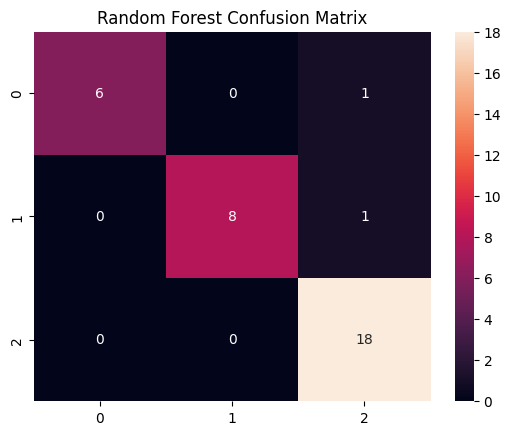

In [90]:
sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## 6.4 XGBoost Classifier

In [91]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [92]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)


In [93]:
print(
    "Accuracy:",
    accuracy_score(y_test, xgb_pred)
)
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.89      0.94         9
           2       0.90      1.00      0.95        18

    accuracy                           0.94        34
   macro avg       0.97      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



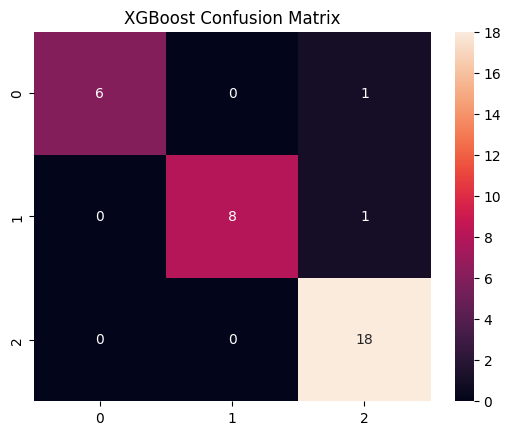

In [94]:
sns.heatmap(
    confusion_matrix(y_test, xgb_pred),
    annot=True,
    fmt="d"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

# 7. Model Evaluation & Comparison

In [95]:
models = {
    "Random Forest": (rf, rf_pred),
    "XGBoost": (xgb, xgb_pred)
}

results = []
for name, (model, pred) in models.items():
    acc = accuracy_score(y_test, pred)
    cv_score = cross_val_score(model, X, y, cv=5, scoring="accuracy").mean()
    results.append({
        "Model": name,
        "Test Accuracy": round(acc, 4),
        "CV Accuracy (5-Fold)": round(cv_score, 4)
    })

comparison = pd.DataFrame(results)
comparison

,Model,Test Accuracy,CV Accuracy (5-Fold)
0,Random Forest,0.9412,0.9581
1,XGBoost,0.9412,0.9579


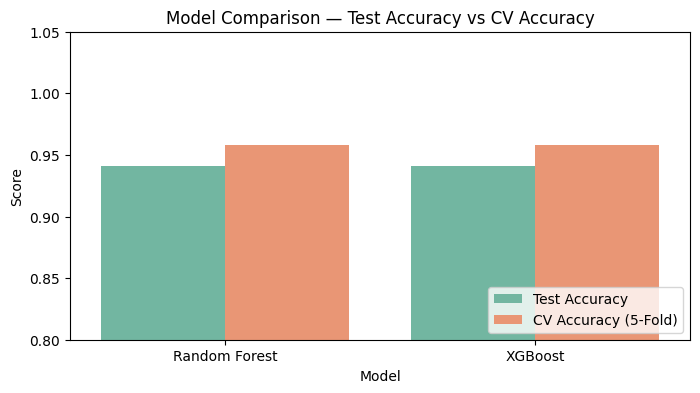

In [96]:
plt.figure(figsize=(8, 4))
comparison_melted = comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(x="Model", y="Score", hue="Metric", data=comparison_melted, palette="Set2")
plt.title("Model Comparison — Test Accuracy vs CV Accuracy")
plt.ylim(0.8, 1.05)
plt.legend(loc="lower right")
plt.show()

# 8. Feature Importance Analysis

## 8.1 Random Forest Feature Importances

In [97]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.231987
8,gdpp,0.221825
6,life_expec,0.209020
7,total_fer,0.171427
4,income,0.117589
2,health,0.015926
5,inflation,0.012177
3,imports,0.012062
1,exports,0.007987


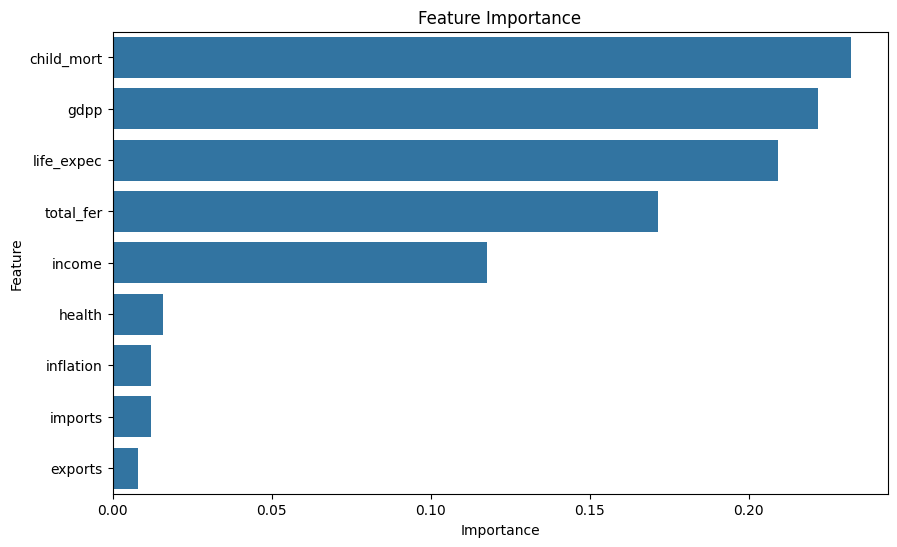

In [98]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

## 8.2 Cluster-wise Country Insights

In [99]:
df[df["Cluster"] == 2][
    ["country","income","gdpp","child_mort"]
].head(20)

,country,income,gdpp,child_mort
1,Albania,9930,4090,16.6
2,Algeria,12900,4460,27.3
4,Antigua and Barbuda,19100,12200,10.3
5,Argentina,18700,10300,14.5
6,Armenia,6700,3220,18.1
9,Azerbaijan,16000,5840,39.2
10,Bahamas,22900,28000,13.8
11,Bahrain,41100,20700,8.6
12,Bangladesh,2440,758,49.4
13,Barbados,15300,16000,14.2
